In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df = pd.read_csv('cust_sent.csv')

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'],dayfirst=True)
newest_customer=df['Dt_Customer'].max()
df['Seniority']=(newest_customer-df['Dt_Customer']).dt.days 

In [9]:
education_map = {
    "Basic":0,"2n Cycle":1,"Graduation":2,"Master":3,"PhD":4
}
df['Education']=df['Education'].map(education_map)

In [10]:
df['Marital_Status']=df['Marital_Status'].replace({
    "Married":"Partner","Together":"Partner","Absurd":"Alone",
    "Divorced": "Alone", "Single": "Alone", "Alone": "Alone"
})

In [11]:
df['Living_with'] = df['Marital_Status'].map({"Partner":1,"Alone":0})

In [12]:
df=df[(2026-df['Year_Birth'])<90]
df = df[df['Income']<200000]
print(f"Rows remaining after cleaning: {len(df)}")

Rows remaining after cleaning: 2212


In [13]:
# 1. Total Spending (The most important metric for customer value)
df["Total_Spent"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + \
                   df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

# 2. Total Purchases (To see how frequently they shop)
df["Total_Purchases"] = df["NumWebPurchases"] + df["NumCatalogPurchases"] + \
                       df["NumStorePurchases"] + df["NumDealsPurchases"]

# 3. Household Evolution (Simplifying family dynamics)
# 'Living_With' was created in step 2.3 (1 for Partner, 0 for Alone)
df["Children"] = df["Kidhome"] + df["Teenhome"]
df["Family_Size"] = 1 + df["Living_with"] + df["Children"]

# 4. Parenthood status
df["Is_Parent"] = (df["Children"] > 0).astype(int)

# 5. Segmenting Education into simpler groups
# Already done in 2.3, but ensure it's numeric for the model.

In [14]:
df['Age']=2026-df['Year_Birth']

In [15]:
#Step-4 Feature selection and scaling
features_to_use = [
    "Age", "Education", "Income", "Seniority", 
    "Total_Spent", "Total_Purchases", "Family_Size", 
    "Is_Parent", "Living_with"
]
df_final=df[features_to_use].copy()

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_final)
df_scaled = pd.DataFrame(scaled_features,columns=df_final.columns)

In [17]:
df_scaled.head()

,Age,Education,Income,Seniority,Total_Spent,Total_Purchases,Family_Size,Is_Parent,Living_with
0,1.018352,-0.458850,0.287105,1.527721,1.676245,1.317945,-1.796462,-1.581139,-1.422204
1,1.274785,-0.458850,-0.260882,-1.189011,-0.963297,-1.159273,0.422728,0.632456,-1.422204
2,0.334530,-0.458850,0.913196,-0.206048,0.280110,0.796425,-0.686867,-1.581139,0.703134
3,-1.289547,-0.458850,-1.176114,-1.060584,-0.920135,-0.898513,0.422728,0.632456,0.703134
4,-1.033114,1.533251,0.294307,-0.951915,-0.307562,0.535666,0.422728,0.632456,0.703134


In [18]:
df_final.isnull().sum()

Age                 0
Education           0
Income              0
Seniority           0
Total_Spent         0
Total_Purchases     0
Family_Size        78
Is_Parent           0
Living_with        78
dtype: int64

In [19]:
# 1. Drop rows with ANY missing values in your final feature set
from sklearn.decomposition import PCA
df_final = df_final.dropna()

print(f"Data shape after final cleaning: {df_final.shape}")

# 2. RE-RUN SCALING (Critical! You must re-fit the scaler on the new data)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_final)

# Re-create the dataframe
df_scaled = pd.DataFrame(scaled_features, columns=df_final.columns)

# 3. NOW run PCA (It should work this time)
pca = PCA(n_components=3)
pca_data = pca.fit_transform(df_scaled)

# 4. Success check
df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2', 'PC3'])
print("PCA Successful!")

Data shape after final cleaning: (2134, 9)
PCA Successful!


In [20]:
print(df_pca.head())

        PC1       PC2       PC3
0  3.187458  1.149898 -0.592044
1 -1.382855  0.522658  1.633394
2  1.706391  0.001639 -0.183762
3 -2.124640  0.509610 -0.141786
4 -0.291262 -0.957855  0.784052


c:\Users\amits\anaconda3\envs\cuda112\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\amits\anaconda3\envs\cuda112\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\amits\anaconda3\envs\cuda112\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\amits\anaconda3\envs\cuda112\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` wi

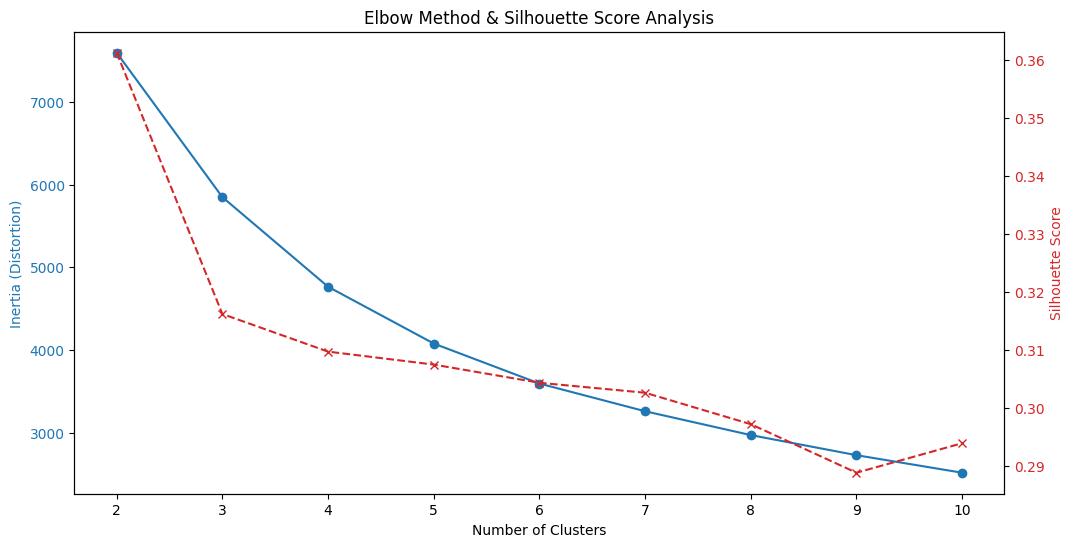

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia=[]
silhouette_scores=[]
range_clusters=range(2,11)

for i in range_clusters:
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_pca,kmeans.labels_))

# Plotting the Elbow Curve and Silhouette Scores
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Inertia (Elbow)
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia (Distortion)', color='tab:blue')
ax1.plot(range_clusters, inertia, marker='o', color='tab:blue', label='Inertia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot Silhouette Score
ax2 = ax1.twinx()  
ax2.set_ylabel('Silhouette Score', color='tab:red') 
ax2.plot(range_clusters, silhouette_scores, marker='x', linestyle='--', color='tab:red', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Elbow Method & Silhouette Score Analysis')
plt.show()